# Toy TB model (SELT(R))

This notebook contains the full model specification and runs the SELT(R) toy model defined in `src/`. For TB epidemiology background and the rationale for this modeling approach, see `tb_overview/modeling_tb.pdf`.

## Model structure

The SELT(R) model has six compartments and tracks total population $N = S + L_\text{fast} + L_\text{slow} + I + T + R$.

The force of infection is $\lambda = \beta \, I / N$.

$$
\frac{dS}{dt} = bN - \lambda S - \mu S
$$

$$
\frac{dL_\text{fast}}{dt} = f \lambda S - \nu_\text{fast} L_\text{fast} - \mu L_\text{fast}
$$

$$
\frac{dL_\text{slow}}{dt} = (1 - f) \lambda S - \nu_\text{slow} L_\text{slow} - \mu L_\text{slow}
$$

$$
\frac{dI}{dt} = \nu_\text{fast} L_\text{fast} + \nu_\text{slow} L_\text{slow} + \rho_T T + \rho_R R - (\tau + \gamma + \delta + \mu) I
$$

$$
\frac{dT}{dt} = \tau I - \rho_T T - \mu T
$$

$$
\frac{dR}{dt} = \gamma I - \rho_R R - \mu R
$$

## Basic reproduction number

An approximate analytical expression for $R_0$, derived via the next-generation matrix:

$$
R_0 = \beta \cdot \frac{1}{\tau + \gamma + \delta + \mu} \cdot \left( f \cdot \frac{\nu_\text{fast}}{\nu_\text{fast} + \mu} + (1 - f) \cdot \frac{\nu_\text{slow}}{\nu_\text{slow} + \mu} \right)
$$

The three terms are: the transmission rate $\beta$, the mean infectious duration $1/(\tau + \gamma + \delta + \mu)$, and the probability that a new infection eventually reaches the infectious compartment (weighted sum over fast and slow progressors).

## Default parameters

These are illustrative toy values chosen to place the model in an epidemiologically plausible range. They are not calibrated to any specific country.

| Parameter | Symbol | Value | Units | Source / note |
|---|---|---|---|---|
| Population size | $N$ | 1,000,000 | persons | project default |
| Birth rate | $b$ | 1/70 | 1/year | ~70-year life expectancy |
| Natural death rate | $\mu$ | 1/70 | 1/year | ~70-year life expectancy |
| Transmission rate | $\beta$ | 12 | 1/year | yields plausible $R_0$ |
| Fast-progressor fraction | $f$ | 0.10 | — | 5–10% early progression (Vynnycky & Fine 1997) |
| Fast progression rate | $\nu_\text{fast}$ | 2.0 | 1/year | progression within months (Vynnycky & Fine 1997) |
| Slow reactivation rate | $\nu_\text{slow}$ | 0.001 | 1/year | long-term reactivation (Vynnycky & Fine 1997) |
| Treatment rate | $\tau$ | 1.0 | 1/year | mean 1-year delay to treatment |
| Self-cure rate | $\gamma$ | 0.2 | 1/year | ~5-year mean self-cure (Tiemersma et al. 2011) |
| TB mortality rate | $\delta$ | 0.2 | 1/year | ~50% 3-year fatality (Tiemersma et al. 2011) |
| Relapse after treatment | $\rho_T$ | 0.02 | 1/year | toy value |
| Reactivation after self-cure | $\rho_R$ | 0.01 | 1/year | toy value |

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import compute_basic_reproduction_number, run_simulation
from src.parameters import ModelParameters, create_default_initial_state
from src.plotting import plot_compartment_timeseries, plot_incident_active_tb

In [2]:
parameters = ModelParameters()
initial_state = create_default_initial_state(parameters)

basic_reproduction_number = compute_basic_reproduction_number(parameters)
print(f"R0 (toy model): {basic_reproduction_number:.2f}")

R0 (toy model): 1.34


In [3]:
start_year = 0.0
end_year = 100.0
time_points = np.linspace(start_year, end_year, 1001)

results = run_simulation(parameters, initial_state, (start_year, end_year), time_points)

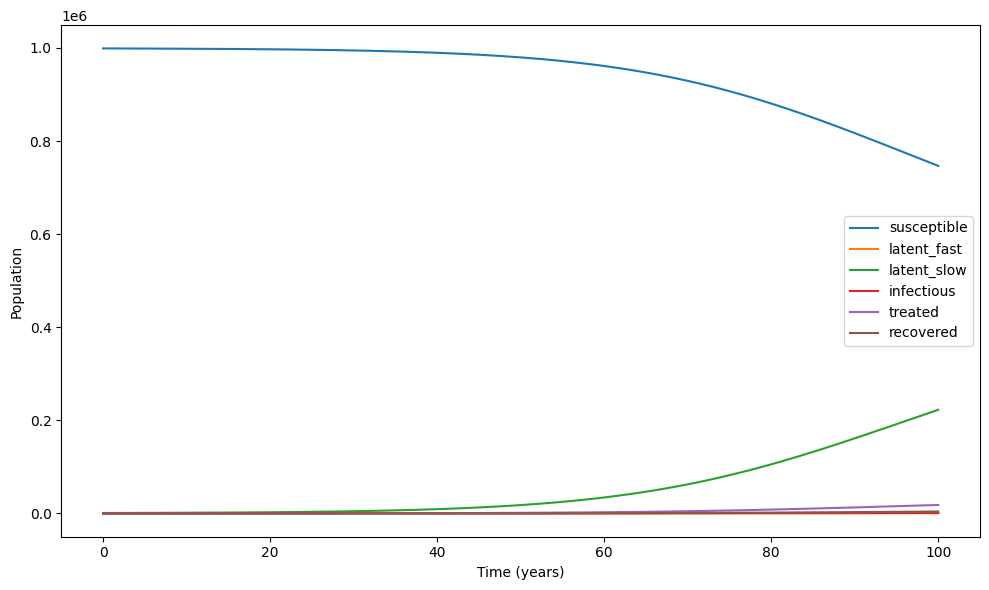

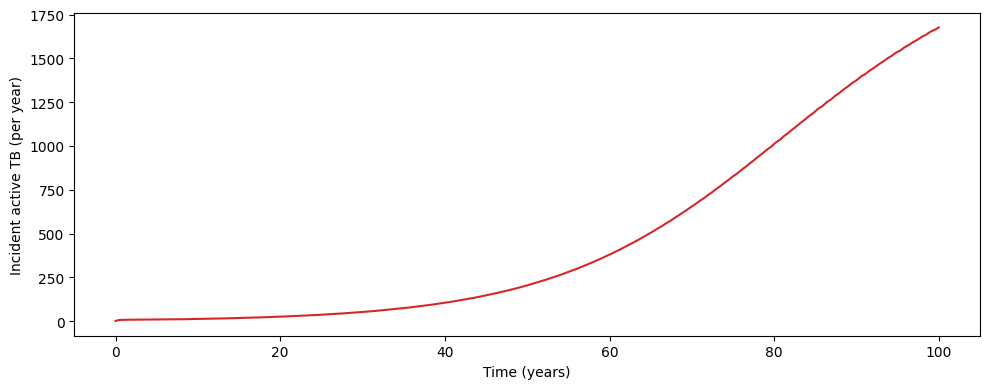

In [4]:
plot_compartment_timeseries(results)
plot_incident_active_tb(results)
plt.show()

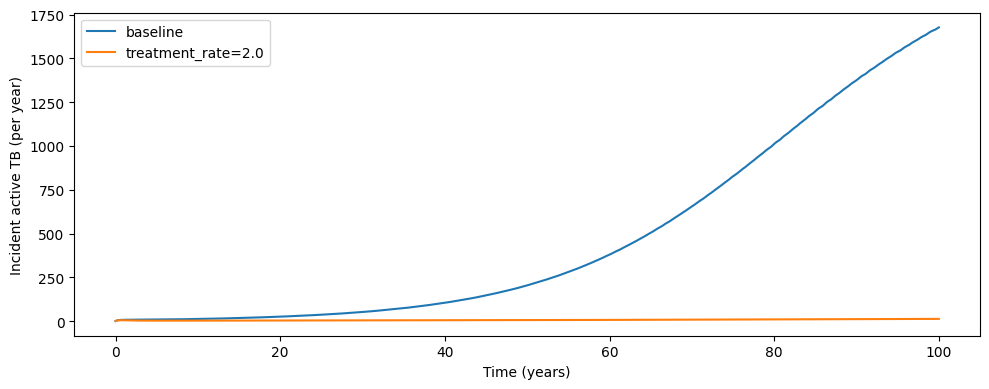

In [5]:
high_treatment_parameters = ModelParameters(treatment_rate=2.0)
high_treatment_initial_state = create_default_initial_state(high_treatment_parameters)
high_treatment_results = run_simulation(
    high_treatment_parameters,
    high_treatment_initial_state,
    (start_year, end_year),
    time_points,
)

plt.figure(figsize=(10, 4))
plt.plot(results["time_years"], results["incident_active_tb"], label="baseline")
plt.plot(
    high_treatment_results["time_years"],
    high_treatment_results["incident_active_tb"],
    label="treatment_rate=2.0",
)
plt.xlabel("Time (years)")
plt.ylabel("Incident active TB (per year)")
plt.legend()
plt.tight_layout()
plt.show()